In [48]:
import pandas as pd

df = pd.read_parquet("velocity_data.parquet")
print(df.shape)
print(df.dtypes)

(4061395, 14)
frame             int64
time            float64
label             int64
x                 int64
y                 int64
dt              float64
dx              float64
dy              float64
vx              float64
vy              float64
velocity        float64
ax              float64
ay              float64
acceleration    float64
dtype: object


In [49]:
VELOCITY_THRESHOLD = 30000
MIN_FRAMES = 100

summary = df.groupby("label").agg(
    n_points=("velocity", "size"),
    duration=("frame", lambda t: t.max() - t.min()),
    max_abs_v=("velocity", lambda v: v.abs().max()),
    frac_zero=("velocity", lambda v: (v == 0).mean()),
).reset_index()

valid_labels = summary[
    (summary["max_abs_v"] > VELOCITY_THRESHOLD)
    & (summary["n_points"] >= MIN_FRAMES)
]["label"].tolist()

print(f"{len(valid_labels)} of {summary.shape[0]} labels kept")
sub = df[df["label"].isin(valid_labels)].sort_values(["label", "frame"])
print(sub.shape)

177 of 8354 labels kept
(824424, 14)


In [50]:
# Save the filtered GUI-equivalent data.
sub.to_parquet("velocity_data_filtered.parquet", compression="zstd", index=False)

In [51]:
from matplotlib import pyplot as plt

results = {}
for lbl in valid_labels:
    track = sub[sub["label"] == lbl].sort_values("frame")
    results[lbl] = {
        "time": track["time"].to_numpy(),
        "velocity": track["velocity"].to_numpy(),
        "acceleration": track["acceleration"].to_numpy(),
    }

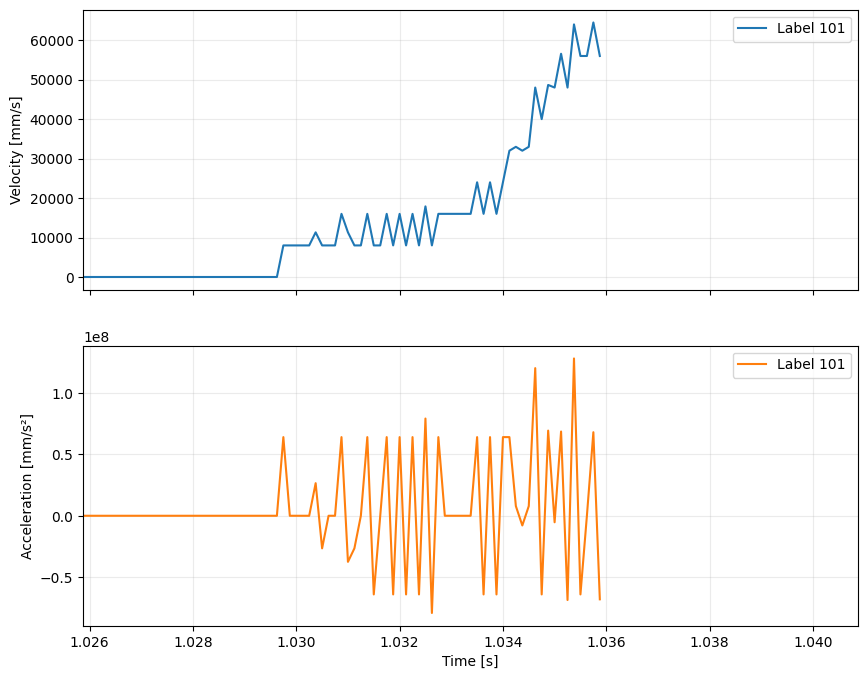

In [67]:
label_to_plot = 101
track_result = results[label_to_plot]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(
    track_result["time"],
    track_result["velocity"],
    label=f"Label {label_to_plot}",
)
axes[0].set_ylabel("Velocity [mm/s]")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    track_result["time"],
    track_result["acceleration"],
    label=f"Label {label_to_plot}",
    color="tab:orange",
)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Acceleration [mm/s²]")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[1].set_xlim(track_result["time"].max()-0.01, track_result["time"].max()+0.005)

plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

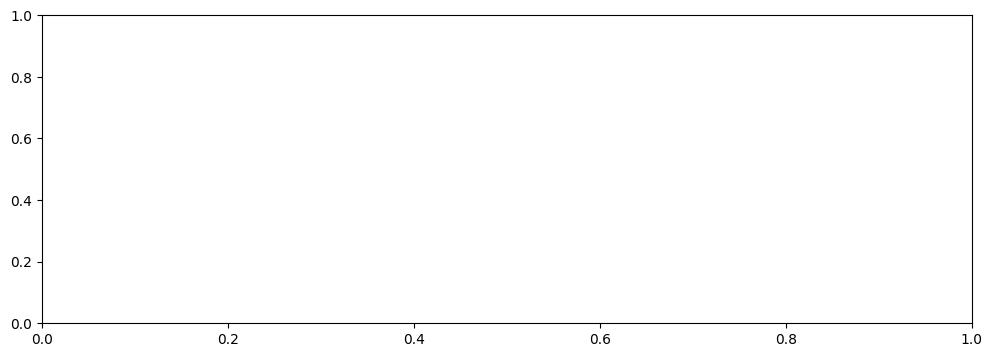

In [ ]:
PIXEL_SIZE_MM = 0.006849
WINDOW_SECONDS = 0.003

# fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig, axes = plt.subplots(1, 1, figsize=(12, 4), sharex=True)

for label_to_plot, track_result in results.items():
    final_time = track_result["time"].max()
    indexes = track_result["time"] > final_time - WINDOW_SECONDS
    time = track_result["time"][indexes] - track_result["time"][indexes].min()

    #try to remove spiky things
    if track_result["velocity"][indexes].max() * PIXEL_SIZE_MM > 2000:
        continue
    elif track_result["velocity"][indexes][-1] * PIXEL_SIZE_MM < 50:
        continue

    axes.plot(
        time,
        track_result["velocity"][indexes] * PIXEL_SIZE_MM,
        linewidth=0.8,
        label=f"Label {label_to_plot}",
    )
    # axes[1].plot(
    #     time,
    #     track_result["acceleration"][indexes] * PIXEL_SIZE_MM,
    #     linewidth=0.8,
    #     label=f"Label {label_to_plot}",
    # )

axes.set_ylabel("Velocity [mm/s]")
axes.set_ylim(0, 2000)
# axes[1].set_ylabel("Acceleration [mm/s²]")
axes.set_xlabel("Time from track end [s]")

# for ax in axes:
axes.grid(alpha=0.25)

# axes[0].legend(
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     fontsize="small",
#     ncol=2,
# )

plt.tight_layout()
plt.show()